## Import packages

In [16]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
import pandas as pd # for creation of data frames
import numpy as np #
import pyls # PLS: behavioral and mean-centered
import seaborn as sns
import nibabel as nib # for loading niftis etc. as arrays
import matplotlib.pyplot as plt # for plotting data
from matplotlib import cm
#the output of plotting commands is displayed inline, directly below the code cell that produced it
%matplotlib inline 
import os,glob
from nilearn import plotting, input_data, image #for plotting & working with niftis
from nilearn import surface
from nilearn import datasets
fsaverage = datasets.fetch_surf_fsaverage()
from scipy import stats
from nilearn import glm

import pathlib

###################### update path!! #####################################
base_path = 'DATAPATH' 
script_path = 'SCRIPT_PATH' 
##########################################################################

#import qBOLD functions
import sys
#sys.path.append(os.path.join(base_path + 'scripts/'))
#import mqBOLD_functions as qB

#import pyxnat
#x = pyxnat.Interface(config='/home/tumnic/sepp/xnat_config.cfg')

#project_id = 'p_fpet_vis' #project ID as displayed in xnat
#project = x.select.project(project_id)
# Check if connection was successful
#project.exists()

os.environ["FSLOUTPUTTYPE"]='NIFTI_GZ'
os.environ["ANTSPATH"] = '/opt/ants/bin'
os.environ["PATH"] += f':{os.environ["ANTSPATH"]}'
os.environ["LD_LIBRARY_PATH"] += ':/opt/ants/lib'

## define variables, please check

In [3]:
data_dir = base_path + '/data'
derivatives_dir = data_dir + '/derivatives'
results_dir = data_dir + '/results'
MNI_2mm_brain = derivatives_dir + '/MNI152_T1_2mm_brain.nii.gz'

sids_overlap = [1, 4, 7, 10, 11, 14, 15, 16, 17, 18, 19, 10] ## N=12, These subjects have both CMRglc and CMRO2
sids=[ 1, 2,  4, 7, 10,11,14, 15, 16, 17, 18, 19, 20 ] ##N=13, only non-pilot data, but including 10!
sids_cmrglc =[ 1, 3,4, 7, 9,10,11, 13,14, 15, 16, 17, 18, 19, 20 ] ## N=15
sids_all = [ 1, 2, 3,4, 7, 9,10,11, 13,14, 15, 16, 17, 18, 19, 20  ] 
sids_cbv = [4, 7, 10, 11, 14, 15, 16, 17, 18, 19, 20 ]


conds = [ 'open', 'checker']

sns.set_style("whitegrid")

coords=(-15, 0, 15, 30, 45, 60, 75, 90)

#######################
## please choose ######
#######################
#CBV_masking='yes'
CBV_masking='no'

if CBV_masking == 'yes':
    ## kick out voxels with CBV > 5.5, plus voxels with low SNR and GM probability < 0.5
    GM_SNR_mask = os.path.join(derivatives_dir, 'N16_space-MNI152_SNR_YEO_CBV_mask.nii.gz')
if CBV_masking == 'no':
    ## leave in all voxels with CBV, only kick out voxles with low SNR and GM probability < 0.5
    GM_SNR_mask = os.path.join(derivatives_dir, 'task-loc_space-MNI152NLin6Asym_res-2_SNR_YEO_group_mask.nii.gz')


### define blue-red colorbar

In [4]:
import matplotlib as mpl
sns.set_style("whitegrid")
from matplotlib.colors import LinearSegmentedColormap

fontsize = 25

colors = ["darkblue", "blue", "dodgerblue",  "whitesmoke","darkorange", "red", "darkred"]
BlueRed = LinearSegmentedColormap.from_list("mycmap", colors)

colors_pos = ["whitesmoke","darkorange", "red", "blueviolet"]
Red_pos = LinearSegmentedColormap.from_list("mycmap", colors_pos)

### define functions

In [5]:
## copied from netneurotools: https://github.com/netneurolab/netneurotools/blob/master/netneurotools/stats.py
def permtest_rel(a, b, axis=0, n_perm=1000, seed=0):
    """
    Non-parametric equivalent of :py:func:`scipy.stats.ttest_rel`
    Generates two-tailed p-value for hypothesis of whether related samples `a`
    and `b` differ using permutation tests
    Parameters
    ----------
    a, b : array_like
        Sample observations. These arrays must have the same shape.
    axis : int or None, optional
        Axis along which to compute test. If None, compute over whole arrays
        of `a` and `b`. Default: 0
    n_perm : int, optional
        Number of permutations to assess. Unless `a` and `b` are very small
        along `axis` this will approximate a randomization test via Monte
        Carlo simulations. Default: 1000
    seed : {int, np.random.RandomState instance, None}, optional
        Seed for random number generation. Set to None for "randomness".
        Default: 0
    Returns
    -------
    stat : float or numpy.ndarray
        Average difference between `a` and `b`
    pvalue : float or numpy.ndarray
        Non-parametric p-value
    Notes
    -----
    The lowest p-value that can be returned by this function is equal to 1 /
    (`n_perm` + 1).
    Examples
    --------
    >>> from netneurotools import stats
    >>> np.random.seed(12345678)  # set random seed for reproducible results
    >>> rvs1 = np.random.normal(loc=5, scale=10, size=500)
    >>> rvs2 = (np.random.normal(loc=5, scale=10, size=500)
    ...         + np.random.normal(scale=0.2, size=500))
    >>> stats.permtest_rel(rvs1, rvs2)  # doctest: +SKIP
    (-0.16506275161572695, 0.8021978021978022)
    >>> rvs3 = (np.random.normal(loc=8, scale=10, size=500)
    ...         + np.random.normal(scale=0.2, size=500))
    >>> stats.permtest_rel(rvs1, rvs3)  # doctest: +SKIP
    (2.40533726097883, 0.000999000999000999)
    """

    a, b, axis = _chk2_asarray(a, b, axis)
    rs = check_random_state(seed)

    if a.shape[axis] != b.shape[axis]:
        raise ValueError('Provided arrays do not have same length along axis')

    if a.size == 0 or b.size == 0:
        return np.nan, np.nan

    # calculate original difference in means
    ab = np.stack([a, b], axis=0)
    if ab.ndim < 3:
        ab = np.expand_dims(ab, axis=-1)
    true_diff = np.squeeze(np.diff(ab, axis=0)).mean(axis=axis) / 1
    abs_true = np.abs(true_diff)

    # idx array
    reidx = np.meshgrid(*[range(f) for f in ab.shape], indexing='ij')

    permutations = np.ones(true_diff.shape)
    for perm in range(n_perm):
        # use this to re-index (i.e., swap along) the first axis of `ab`
        swap = rs.random_sample(ab.shape[:-1]).argsort(axis=axis)
        reidx[0] = np.repeat(swap[..., np.newaxis], ab.shape[-1], axis=-1)
        # recompute difference between `a` and `b` (i.e., first axis of `ab`)
        pdiff = np.squeeze(np.diff(ab[tuple(reidx)], axis=0)).mean(axis=axis)
        permutations += np.abs(pdiff) >= abs_true

    pvals = permutations / (n_perm + 1)  # + 1 in denom accounts for true_diff

    return true_diff, pvals

# OGI

In [6]:
## save OGI per subject, qBOLD masked
OGI_list = []
for i, ID in enumerate(sids_overlap): #loop over subjects, only those that have both CMRO2 and CMRglc
    sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
    sid = "fp{:03d}".format(ID+8) # subject id, eg 'p021'
    subname = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'

    sub_dir = os.path.join(data_dir, sub)

    dir_deriv = os.path.join(derivatives_dir, sub)
                
    for cond in conds:
        ## CMRO2

        CMRO2_nii = os.path.join(dir_deriv, 'qmri', sub+'_task-'+cond+'_space-T2_cmro2_qBmasked.nii.gz')
        if cond == 'checker' and ID > 2:
            #CMRO2_nii = os.path.join(dir_deriv, 'qmri', sub+'_task-'+cond+'_space-T2_desc-30perc_cmro2_qBmasked.nii.gz')
            CMRO2_nii = os.path.join('/home/tumnic/sepp/neuroenergeticslab_notebooks/p_fpet_vis/tmp/'+sid+'/qBOLD/task-checker/CMRO2_noCBV_qBmasked.nii.gz') 


        ## CMRglc
        CMRglc_nii = os.path.join(dir_deriv, 'fpet', sub+ '_glm_task-'+cond+'_space-T2_cmrglc_qBmasked.nii.gz')
        
        ## OGI per voxel
        OGI = np.array(nib.load(CMRO2_nii).dataobj) / np.array(nib.load(CMRglc_nii).dataobj)
        OGI[np.isinf(OGI)]=np.nan ## values to nan that are inf
        OGI[OGI<=0] = np.nan ## voxels to nan that are 0 and below
        OGI_GM_median= np.nanmedian(OGI)
        print(subname + '  ' + cond + ' OGI GM median: ' + str(OGI_GM_median))
        
        OGI_nifti= nib.Nifti1Image(OGI, nib.load(CMRO2_nii).affine)
        
        nib.save(OGI_nifti, os.path.join(dir_deriv, 'qmri', sub+'_task-'+cond+'_OGI_qBmasked.nii.gz'))
        
        ## for later gray-matter median across all subjects an all voxels, in rest
        OGI_array= OGI[OGI>=0]
        OGI_list.append(OGI_array)
        

## calculate gray-matter median across all subjects an all voxels, in rest
GM_OGI = np.concatenate(OGI_list).ravel()
GM_OGI_median = np.nanmedian(GM_OGI)
print('GM median OGI across all subjects an voxels: ' + str(GM_OGI_median))

## compute median absolute deviation from gray-matter median
OGI_GM_abs_dev = np.nanmedian([abs(number-GM_OGI_median) for number in GM_OGI[~np.isnan(GM_OGI)]])

## compute threshold: 
#OGI_GM_threshold = GM_OGI_median + 5 * OGI_GM_abs_dev
OGI_GM_threshold = GM_OGI_median + 3 * OGI_GM_abs_dev
print('upper OGI threshold: ' + str(OGI_GM_threshold))
#OGI_GM_lowthreshold = GM_OGI_median - 5 * OGI_GM_abs_dev
OGI_GM_lowthreshold = GM_OGI_median - 3 * OGI_GM_abs_dev
print('lower OGI threshold: ' + str(OGI_GM_lowthreshold))


sub-fp001  open OGI GM median: 4.913070595071066
sub-fp001  checker OGI GM median: 4.465980306920977
sub-fp004  open OGI GM median: 4.095336606437197
sub-fp004  checker OGI GM median: 4.108773903311285
sub-fp007  open OGI GM median: 3.9506449313575533
sub-fp007  checker OGI GM median: 4.063951051456154
sub-fp010  open OGI GM median: 5.080337319752219
sub-fp010  checker OGI GM median: 4.4947979577859645
sub-fp011  open OGI GM median: 5.6351794329874005
sub-fp011  checker OGI GM median: 5.660993099413686
sub-fp014  open OGI GM median: 7.762435508202145
sub-fp014  checker OGI GM median: 7.143239603051683
sub-fp015  open OGI GM median: 4.191050740757831
sub-fp015  checker OGI GM median: 4.089402809657386
sub-fp016  open OGI GM median: 4.491472696511928
sub-fp016  checker OGI GM median: 3.803959352791943
sub-fp017  open OGI GM median: 3.9688694832210123
sub-fp017  checker OGI GM median: 4.127726090012778
sub-fp018  open OGI GM median: 5.333672459838186
sub-fp018  checker OGI GM median: 5.05

## Fig 3 A: Difference in OGI between REST and STIM

wholebrain_GM
64696
sub-fp001
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp010
p-value = 9.761538640019229e-05
PLS_BOLD
4126
sub-fp001
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp010
p-value = 0.003084598558502794
PLS_CMRglc
1892
sub-fp001
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp010
p-value = 0.0010753767199976913


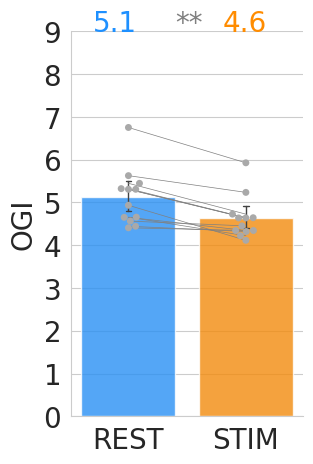

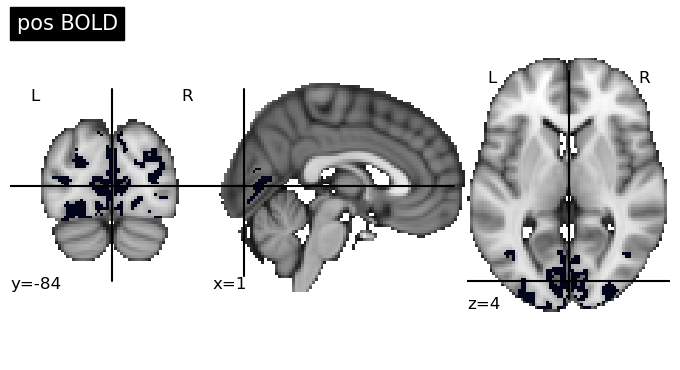

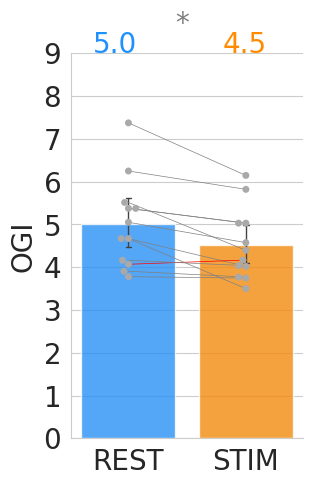

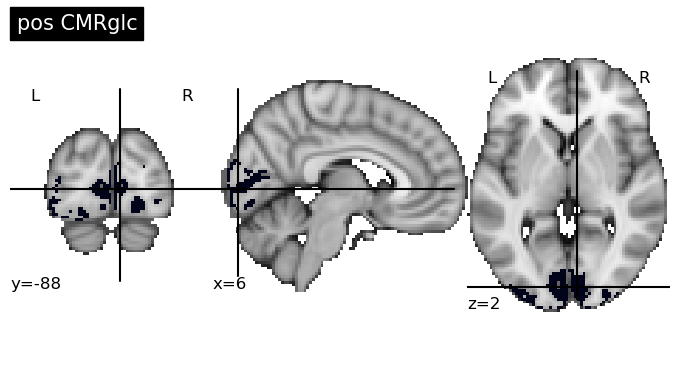

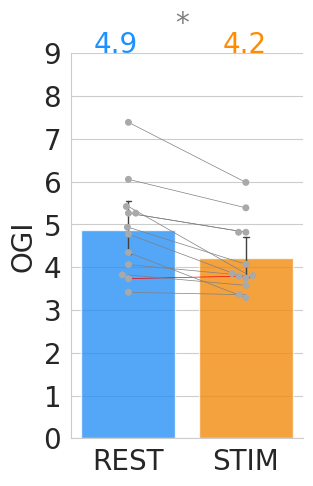

In [8]:
fontsize = 20
plt.rcParams['legend.title_fontsize'] = 'x-large'
sns.set_style("whitegrid")
BSR_thr = 2


mask_img = nib.load(GM_SNR_mask)
masker = input_data.NiftiMasker(mask_img=GM_SNR_mask) ## exclude areas with too less SNR (based on the localizer data)
mask_arr = np.array(mask_img.dataobj)


##########################################################
## please select which group task mask to apply!! ##
##########################################################

#masks = ['PLS CBF', 'PLS CMRO2', 'PLS OEF']
masks = [ 'wholebrain_GM', 'PLS_BOLD', 'PLS_CMRglc']


##########################################################
## please select which parameters you want to look at! ##
##########################################################


for mask in masks:
    print(mask)
    
    if mask == 'PLS_BOLD':
        #if CBV_masking == 'yes':
        #    BSR_nii = nib.load(results_dir + '/N' + str(len(sids))  + '_meanPLS_BOLD_LV1_BSR_clust_z' + str(BSR_thr)+ '_pos_mask.nii.gz')
        if CBV_masking == 'no':
            mask_nii = nib.load(os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_GLM_BOLD_2ndlevel_mask.nii.gz'))
        plotting.plot_img(mask_nii, bg_img=MNI_2mm_brain,threshold=0.1, title ='pos BOLD' )
    
    if mask == 'PLS_CBF':
        if CBV_masking =='yes':
            BSR_nii = nib.load(results_dir + '/N' + str(len(sids))  + '_meanPLS_CBF_LV1_BSR_clust_z' + str(BSR_thr)+ '_pos_mask.nii.gz')
        if CBV_masking == 'no':
            mask_nii = nib.load(results_dir + '/N' + str(len(sids))  + '_meanPLS_CBF_LV1_BSR_clust_z' + str(BSR_thr)+ '_pos_mask_noCBVmask.nii.gz')
        plotting.plot_img(mask_nii, bg_img=MNI_2mm_brain,threshold=0.1, title ='pos CBF' )
    
    if mask == 'PLS_CMRglc':
        #if CBV_masking == 'yes':
        #    BSR_nii = nib.load(results_dir + '/N' + str(len(sids_cmrglc))  + '_meanPLS_CMRglc_LV1_BSR_clust_z' + str(BSR_thr)+ '_pos_mask.nii.gz')
        if CBV_masking == 'no':
            mask_nii = nib.load(os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_2ndlevel_mask.nii.gz'))
        plotting.plot_img(mask_nii, bg_img=MNI_2mm_brain,threshold=0.1, title ='pos CMRglc' )
    

    if mask == 'wholebrain_GM':
        mask_nii = nib.load(GM_SNR_mask)       
    
    masker_pos = input_data.NiftiMasker(mask_img=mask_nii) 
    mask_arr = np.array(mask_nii.dataobj)
    print(str(len(mask_arr[mask_arr!=0])))
        
    OGI_rest_subj = np.zeros(len(sids_overlap)) 
    OGI_stim_subj = np.zeros(len(sids_overlap))
    
    for i, ID in enumerate(sids_overlap): #loop over subjects
        sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
        sid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
        print(sid)

        sub_dir = os.path.join(data_dir, sub)
        dir_deriv = os.path.join(derivatives_dir, sub)
        OGI_rest_nii=os.path.join(dir_deriv, 'qmri', sub+'_task-open_space-MNI152_OGI_qBmasked.nii.gz')
        OGI_stim_nii=os.path.join(dir_deriv, 'qmri', sub+'_task-checker_space-MNI152_OGI_qBmasked.nii.gz')

        OGI_rest= masker_pos.fit_transform(OGI_rest_nii).flatten()
        OGI_stim= masker_pos.fit_transform(OGI_stim_nii).flatten()
    
        ## turn 0s into NaNs
        OGI_rest[OGI_rest<=0.01] = np.nan
        OGI_stim[OGI_stim<=0.01] = np.nan
        
        ## for each subject: kick out values below OGI threshold and values that are zero, then take mean        
        OGI_rest[OGI_rest>OGI_GM_threshold] = np.nan
        OGI_stim[OGI_stim>OGI_GM_threshold] = np.nan       
        
        OGI_rest_mean = np.nanmean(OGI_rest)
        OGI_stim_mean = np.nanmean(OGI_stim)
           
        OGI_rest_subj[i] =  OGI_rest_mean                    
        OGI_stim_subj[i] =  OGI_stim_mean                    
    
    df_OGI_stim_open = pd.DataFrame({'rest':OGI_rest_subj, 'stim':OGI_stim_subj})

    ## paired t-test if subjects are normally distributed
    p = stats.ttest_rel(OGI_rest_subj, OGI_stim_subj, axis=0, nan_policy='propagate', alternative='two-sided')
    p_val = p[1]
    print('p-value = ' + str(p_val))
  
    
    ## get colors for line, depending if percchange is negative or positive
    ID_colour_code=[]
    for s in range(0, len(sids_overlap)):
        if OGI_rest_subj[s] - OGI_stim_subj[s] >0:
                ID_colour_code.append('gray')
        if OGI_rest_subj[s] - OGI_stim_subj[s] <0:
                ID_colour_code.append('red')        
    
    
    fig, ax = plt.subplots(1, figsize=(3,5))
    ax = sns.barplot(data=df_OGI_stim_open, estimator=np.mean, ci=95, capsize=.05, n_boot=2000, errwidth=1,
                     palette=['dodgerblue','darkorange'], saturation=0.9, alpha=0.8)
    ax = sns.swarmplot(data=df_OGI_stim_open, palette=['darkgray','darkgray'])
    for line, ID in enumerate(sids_overlap): # for each subject separately
        ax.plot((OGI_rest_subj[line],OGI_stim_subj[line]),   
                  linewidth=0.5, color=ID_colour_code[line]) #plot lines = subjects 
        
    ax.text(-0.3, 9, str(round(np.mean(df_OGI_stim_open['rest']), 1)), color='dodgerblue', fontsize=fontsize, alpha=1)
    ax.text(0.8, 9, str(round(np.mean(df_OGI_stim_open['stim']), 1)), color='darkorange', fontsize=fontsize, alpha=1)
    if p_val<0.001:
        ax.text(0.4, 9, '**' , color='grey', fontsize=fontsize, alpha=1)
    #    ax.hlines(9, 0, 1, colors='grey', linestyles='solid')
    if p_val<0.05 and p_val>0.001:
        ax.text(0.4, 9.5, '*' , color='grey', fontsize=fontsize, alpha=1)
        #ax.hlines(9, 0, 1, colors='grey', linestyles='solid')

    ax.set_ylabel('OGI', fontsize=fontsize)
    ax.set_xticklabels(('REST', 'STIM'), fontsize=fontsize)
    ax.set_ylim(0, 9)

    for pos in ['right', 'top']:
        ax.spines[pos].set_visible(False)

    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(fontsize)

    if CBV_masking == 'yes':
        fig.savefig(results_dir + '/N' + str(len(sids_overlap)) +'_mask_' + mask + '_OGI_checker_vs_open.png', dpi=300, bbox_inches='tight')
    if CBV_masking == 'no':
        fig.savefig(results_dir + '/N' + str(len(sids_overlap)) +'_mask_' + mask + '_OGI_checker_vs_open_noCBVmask.png', dpi=300, bbox_inches='tight')
    fig.show()

## Fig 3A: Difference in OGI between STIM and REST within different masks; in subject-space!!

wholebrain_GM
sub-fp004
43470
sub-fp004 rest mean OGI: 4.401840038701298
sub-fp004 stim mean OGI: 4.250898895968131
sub-fp007
43947
sub-fp007 rest mean OGI: 4.269307104016763
sub-fp007 stim mean OGI: 4.239997279312669
sub-fp010
54346
sub-fp010 rest mean OGI: 5.043169312783078
sub-fp010 stim mean OGI: 4.400522923534216
sub-fp011
54728
sub-fp011 rest mean OGI: 5.485088289974007
sub-fp011 stim mean OGI: 5.126908428188642
sub-fp014
49773
sub-fp014 rest mean OGI: 6.639091350704928
sub-fp014 stim mean OGI: 6.001380701434749
sub-fp015
57177
sub-fp015 rest mean OGI: 4.471829691574637
sub-fp015 stim mean OGI: 4.109105942313185
sub-fp016
54216
sub-fp016 rest mean OGI: 4.64133452813101
sub-fp016 stim mean OGI: 3.973288894450097
sub-fp017
55803
sub-fp017 rest mean OGI: 4.248779393953317
sub-fp017 stim mean OGI: 4.235567486167724
sub-fp018
54678
sub-fp018 rest mean OGI: 5.170275211155813
sub-fp018 stim mean OGI: 4.5929673702505065
sub-fp019
52380
sub-fp019 rest mean OGI: 4.527588855752277
sub-fp019

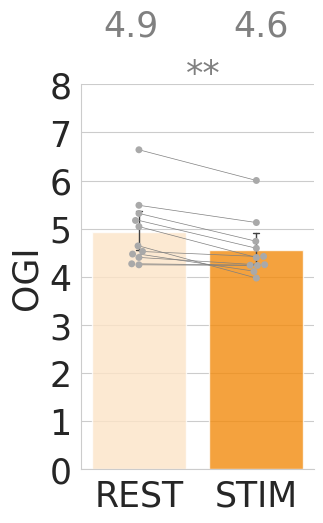

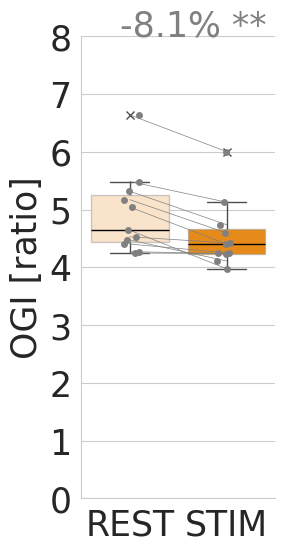

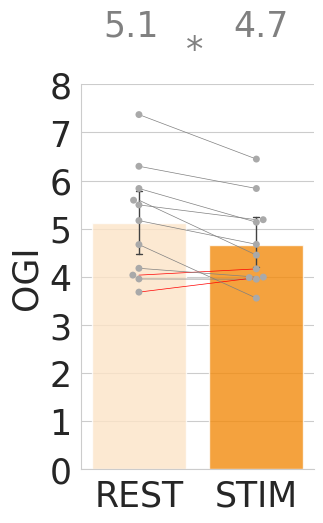

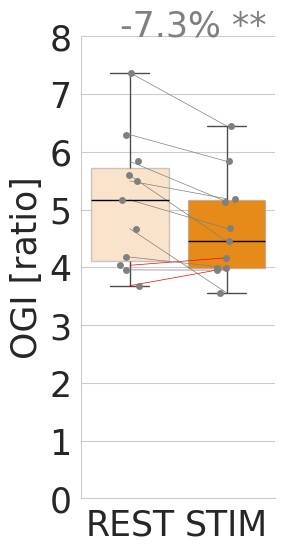

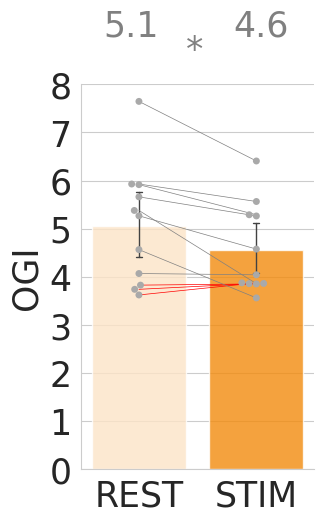

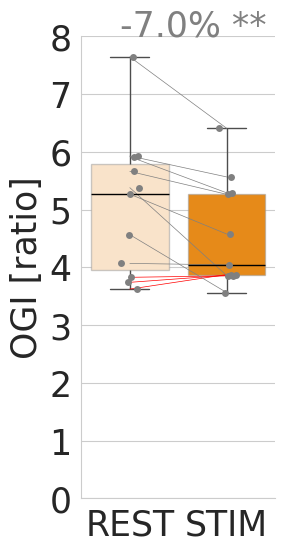

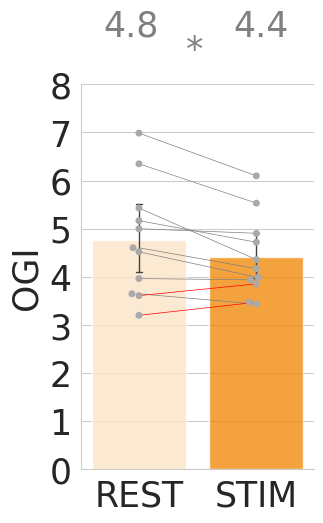

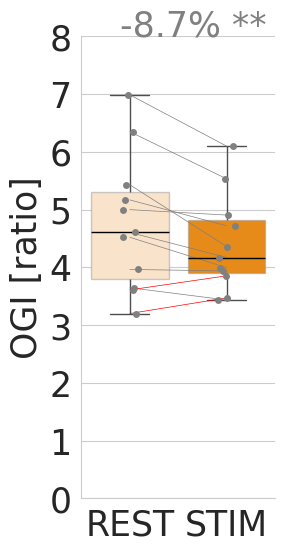

In [9]:
plt.rcParams['legend.title_fontsize'] = 'x-large'
sns.set_style("whitegrid")
BSR_thr = 2

labels=['REST', 'STIM']
fontsize = 25
##define your colour palette
my_colors_act = [ 'bisque', 'darkorange'] 

##########################################################
## please select which group task mask to apply!! ##
##########################################################


#masks = [ 'wholebrain_GM', 'GLM_BOLD', 'GLM_CMRglc', 'PLS_CMRO2', 'CBF']
masks = [ 'wholebrain_GM', 'GLM_BOLD', 'GLM_CMRglc', 'PLS_CMRO2']
#masks = [ 'wholebrain_GM']

##########################################################
## please select which parameters you want to look at! ##
##########################################################

### First: mask OGI for every subject
## 2. create median per subject within mask
## 3. plot boxplot, one dot = one subject
sids_overlap=sids_cbv
for mask in masks:
    print(mask)
        
    OGI_rest_subj = np.zeros(len(sids_overlap)) 
    OGI_stim_subj = np.zeros(len(sids_overlap))
    percchange = np.zeros(len(sids_overlap))
    for i, ID in enumerate(sids_overlap): #loop over subjects
        sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
        sid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
        print(sid)

        sub_dir = os.path.join(data_dir, sub)
        dir_deriv = os.path.join(derivatives_dir, sub)
        OGI_rest_nii=os.path.join(dir_deriv, 'qmri', sub+'_task-open_OGI_qBmasked.nii.gz')
        OGI_stim_nii=os.path.join(dir_deriv, 'qmri', sub+'_task-checker_OGI_qBmasked.nii.gz')
        T1_T2space = os.path.join(dir_deriv, 'qmri', sub + '_space-T2_T1w.nii')


        if mask == 'GLM_BOLD':
            #mask_nifti = os.path.join(dir_deriv, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')
            masked_nifti = os.path.join(dir_deriv, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
            #! fslmaths {mask_nifti} -bin {masked_nifti}
            mask_nii = nib.load(masked_nifti)
            #plotting.plot_img(mask_nii, bg_img=T1_T2space,threshold=0.1, title ='pos BOLD' )
        
        if mask == 'GLM_CMRglc':
            #mask_nifti = os.path.join(dir_deriv, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')
            masked_nifti=os.path.join(dir_deriv, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
            #! fslmaths {mask_nifti} -bin {masked_nifti}
            mask_nii = nib.load(masked_nifti)
            #plotting.plot_img(mask_nii, bg_img=T1_T2space,threshold=0.1, title ='pos CMRglc' )        
    
        if mask == 'PLS_CMRO2':
            #mask_nifti = os.path.join(dir_deriv, 'fpet', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')
            masked_nifti=os.path.join(dir_deriv, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
            #! fslmaths {mask_nifti} -bin {masked_nifti}
            mask_nii = nib.load(masked_nifti)
            
        if mask == 'wholebrain_GM':
            bold_nifti = os.path.join(dir_deriv, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
            masked_nifti = os.path.join(dir_deriv, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin_inverse.nii.gz')
            GM =  os.path.join(dir_deriv, 'qmri', sub + '_space-T2_GM_mask.nii.gz')
            # generate inverse mask
            ! fslmaths {bold_nifti} -bin  -binv -mas {GM} {masked_nifti}
            
            mask_nii = nib.load(masked_nifti)
            #plotting.plot_img(masked_nifti, bg_img=T1_T2space,threshold=0.1, cmap='jet', title ='pos CMRglc' )        

        if mask == 'CBF':
            masked_nifti =os.path.join(dir_deriv, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
            mask_nii = nib.load(masked_nifti)

            
        masker_pos = input_data.NiftiMasker(mask_img=mask_nii) 
        mask_arr = np.array(mask_nii.dataobj)
        print(str(len(mask_arr[mask_arr!=0])))

        OGI_rest= masker_pos.fit_transform(OGI_rest_nii).flatten()
        OGI_stim= masker_pos.fit_transform(OGI_stim_nii).flatten()
    
        ## turn 0s and negative values into NaNs
        OGI_rest[OGI_rest<=0.01] = np.nan
        OGI_stim[OGI_stim<=0.01] = np.nan
        
        ## for each subject: kick out values below OGI threshold and values that are zero, then take mean        
        OGI_rest[OGI_rest>OGI_GM_threshold] = np.nan
        OGI_stim[OGI_stim>OGI_GM_threshold] = np.nan       
        
        OGI_rest_mean = np.nanmean(OGI_rest)
        print(sid + ' rest mean OGI: ' + str(OGI_rest_mean))
        OGI_stim_mean = np.nanmean(OGI_stim)
        print(sid + ' stim mean OGI: ' + str(OGI_stim_mean))
           
        OGI_rest_subj[i] =  OGI_rest_mean                    
        OGI_stim_subj[i] =  OGI_stim_mean             

        percchange_par = (OGI_stim_subj[i]  - OGI_rest_subj[i]) / OGI_rest_subj[i] * 100
    
            ## store in array for every subject
        percchange[i] = np.nanmedian(percchange_par)
    
    df_OGI_stim_open = pd.DataFrame({'rest':OGI_rest_subj, 'stim':OGI_stim_subj})


    ## paired t-test if subjects are normally distributed
    p = stats.ttest_rel(OGI_rest_subj, OGI_stim_subj, axis=0, nan_policy='propagate', alternative='two-sided')
    p_val = p[1]
    print('p-value = ' + str(p_val))
  
    
    ## get colors for line, depending if percchange is negative or positive
    ID_colour_code=[]
    for s in range(0, len(sids_overlap)):
        if OGI_rest_subj[s] - OGI_stim_subj[s] >0:
                ID_colour_code.append('gray')
        if OGI_rest_subj[s] - OGI_stim_subj[s] <0:
                ID_colour_code.append('red')        
    
    
    ### barplots ###
    fig, ax = plt.subplots(1, figsize=(3,5))
    ax = sns.barplot(data=df_OGI_stim_open, estimator=np.mean, ci=95, capsize=.05, n_boot=2000, errwidth=1,
                     palette=['bisque','darkorange'], saturation=0.9, alpha=0.8)
    ax = sns.swarmplot(data=df_OGI_stim_open, palette=['darkgray','darkgray'])
    for line, ID in enumerate(sids_overlap): # for each subject separately
        ax.plot((OGI_rest_subj[line],OGI_stim_subj[line]),   
                  linewidth=0.5, color=ID_colour_code[line]) #plot lines = subjects 
        
    ax.text(-0.3, 9, str(round(np.mean(df_OGI_stim_open['rest']), 1)), color='grey', fontsize=fontsize, alpha=1)
    ax.text(0.8, 9, str(round(np.mean(df_OGI_stim_open['stim']), 1)), color='grey', fontsize=fontsize, alpha=1)
    if p_val<0.001:
        ax.text(0.4, 8, '**' , color='grey', fontsize=fontsize, alpha=1)
    #    ax.hlines(9, 0, 1, colors='grey', linestyles='solid')
    if p_val<0.05 and p_val>0.001:
        ax.text(0.4, 8.5, '*' , color='grey', fontsize=fontsize, alpha=1)
        #ax.hlines(9, 0, 1, colors='grey', linestyles='solid')

    ax.set_ylabel('OGI', fontsize=fontsize)
    ax.set_xticklabels(('REST', 'STIM'), fontsize=fontsize)
    ax.set_ylim(0, 8)

    for pos in ['right', 'top']:
        ax.spines[pos].set_visible(False)

    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(fontsize)

    if CBV_masking == 'yes':
        fig.savefig(results_dir + '/N' + str(len(sids_overlap)) +'_mask_' + mask + '_OGI_checker_vs_open.png', dpi=300, bbox_inches='tight')
    if CBV_masking == 'no':
        fig.savefig(results_dir + '/N' + str(len(sids_overlap)) +'_mask_' + mask + '_OGI_checker_vs_open_noCBVmask.png', dpi=300, bbox_inches='tight')
    fig.show()
    

    ### boxplots ###
    fig, ax = plt.subplots(1,figsize=(2.5,6))
    sns.boxplot(data = [OGI_rest_subj, OGI_stim_subj],  orient='v', ax=ax,palette=my_colors_act, saturation=0.8,
                       boxprops={"edgecolor": (.6, .6, .6, .5)}, flierprops={"marker": "x"},
                       medianprops={"color": "black"})
    sns.stripplot(data = [OGI_rest_subj, OGI_stim_subj], orient='v', ax=ax, color='grey')
    for line, ID in enumerate(sids_overlap): # for each subject separately
            ax.plot([0, 1], [OGI_rest_subj[line], OGI_stim_subj[line]],   
                      linewidth=0.5, color=ID_colour_code[line]) #plot lines = subjects 

    ## plot significance

    xval=0.65
    xlabel='OGI [ratio]'
    ylimit=8
        

    if p_val<0.001:
            ax.text(-0.1, ylimit , str(round(np.nanmedian(percchange), 1))+'%' + ' **', color='grey', fontsize=fontsize, alpha=1)

    if p_val<0.05 and p_val>0.001:
            ax.text(-0.1, ylimit, str(round(np.nanmedian(percchange), 1))+'%' + ' **', color='grey', fontsize=fontsize, alpha=1)

    
    ax.set_ylim(0, ylimit)
        
    ax.set_ylabel(xlabel, fontsize=fontsize)
    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks((0,1), labels=labels)
    ax.set_xticklabels(['REST', 'STIM'], size = fontsize)

    for pos in ['right', 'top']:
                ax.spines[pos].set_visible(False)

    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
                label.set_fontsize(fontsize)

    fig.show()

    fig.savefig(os.path.join(results_dir,  'N'+str(len(sids)) + '_ROIanalysis_OGI_'+mask+'.png'), dpi=300, bbox_inches='tight')

## Fig. 3B&C

In [24]:
## mask parameter maps with z-stat mask (qB masked)
parameters = ['cbf', 'cmro2', 'cmrglc','oef','ogi'] #'BOLD', ,'ogi'
#parameters = ['oef']

labels=['REST', 'STIM']
fontsize = 25
sns.set_style("whitegrid")
##define your colour palette

my_colors_act = [ 'bisque', 'darkorange']
my_colors_deact = [ 'lightskyblue', 'dodgerblue']

masks=['BOLD', 'fPET', 'CMRO2', 'CBF', 'wholebrain_GM', 'GMwoBOLD'] #['BOLDonly', 'CBFonly'] #'wholebrain_GM' #['GMwoBOLD']#['GMwoVIS']#
#masks=['CBF']
###added###
OGI_GM_threshold = 10.277441026835927 ##Taken from manuscript Fig 3
participants_info_df = pd.read_csv(os.path.join(data_dir,'participants.tsv'),sep='\t')
atlas_dict = datasets.fetch_atlas_schaefer_2018(n_rois=100,resolution_mm=2)
atlas_fn = atlas_dict['maps']
atlas_labels = atlas_dict['labels']
atlas_labels_df = pd.DataFrame({'labels':atlas_labels})#.convert_dtypes()
atlas_labels_df['labels']=atlas_labels_df['labels'].astype('string')
atlas_labels_df['roi_id'] = atlas_labels_df.index + 1
atlas_labels_df['nw'] = atlas_labels_df['labels'].str.split('_').str[2]
atlas_dict['roi2nw'] = dict(zip(atlas_labels_df['roi_id'],atlas_labels_df['nw']))
ogi_dif_roi_df = pd.DataFrame(columns=['sid', 'mask','parameter','roi_id','delta'])
if 'ogi_hcpex_df' not in locals():
    ogi_hcpex_df = pd.DataFrame(columns=['sid', 'mask','parameter','roi_id','rest'])
if 'ogi_sch100_df' not in locals():
    ogi_sch100_df = pd.DataFrame(columns=['sid', 'mask','parameter','roi_id','rest','stim','delta'])
if 'nvc_params_df' not in locals():
    nvc_params_df = pd.DataFrame(columns=['parameter', 'sid', 'sex', 'age', 'rest', 'task', 'perc_change','gm2totalvol','mask', 'rest_pvc', 'task_pvc', 'perc_change_pvc','gm_pve','csf_pve'])
for mask in ['CMRO2','GMwoBOLD']:
    print(f'{mask} MASK')
    for par in parameters: 
        print(f'{par}')
        if par != 'cmrglc':
            sids=[ 9, 10, 12, 15, 18, 19, 22, 23, 24, 25, 26, 27, 28 ]
        if par == 'cmrglc':
            sids=[9, 11, 12, 15, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28]
        if (par == 'ogi') | (mask == 'GMwoVIS'):
            sids=sids_overlap
            
        percchange = np.zeros((len(sids)))   
        par_rest_masked = np.zeros((len(sids))) 
        par_task_masked = np.zeros((len(sids))) 
        
        for i, ID in enumerate(sids): #loop over subjects
            sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
            sid = "sub-{:03d}".format(ID+8) # subject id, eg 'p021'
            #print(sub)
    
            subjfolder = os.path.join(data_dir, 'derivatives', sub)
            dir_deriv = os.path.join(derivatives_dir, sub)
    
            if mask == 'BOLD':
                zstat_mask = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')
                zstat_mask_bin = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
                
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
            
            if mask == 'fPET':
                zstat_mask =os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
                zstat_mask_bin =os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
                
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  

            if mask == 'CMRO2':
                zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
                zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
                
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
                
            if mask == 'CBF':
                zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
                zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
                
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  

            if mask == 'BOLDonly':
                zstat_mask_bin = os.path.join(sid, sub + '_N14_GLM_BOLDonly_2ndlevel_mask_space-T2.nii.gz')                
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  

            if mask == 'CBFonly':
                zstat_mask_bin = os.path.join(sid, sub + '_N14_PLS_CBFonly_2ndlevel_mask_space-T2.nii.gz')                
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  

            if mask == 'wholebrain_GM':
                zstat_mask_bin = os.path.join(subjfolder, 'qmri', sub + '_space-T2_GM_mask.nii.gz')
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)

            if mask == 'GMwoVIS':
                gmwovis_mask_fn = os.path.join(sid, sub + '_space-T2_GMwoVIS_mask.nii.gz')
                if not os.path.exists(gmwovis_mask_fn):
                    gm_mask_fn = os.path.join(subjfolder, 'qmri', sub + '_space-T2_GM_mask.nii.gz')
                    vis_mask_fn = os.path.join(subjfolder, 'qmri', sub + '_space-T2_VIS.nii.gz')
                    !fslmaths {gm_mask_fn} -sub {vis_mask_fn} -thr 0.5 -bin {gmwovis_mask_fn}
                    plotting.plot_roi(gmwovis_mask_fn,bg_img=gm_mask_fn,cmap='Set2',title=sub)
                zstat_mask_bin = gmwovis_mask_fn
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)                    

            if mask == 'GMwoBOLD':
                zstat_mask_bin = os.path.join(sid, sub + '_space-T2_GMwoBOLD_mask.nii.gz')
                if not os.path.exists(zstat_mask_bin):
                    gm_mask_fn = os.path.join(subjfolder, 'qmri', sub + '_space-T2_GM_mask.nii.gz')
                    vis_mask_fn = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
                    !fslmaths {gm_mask_fn} -sub {vis_mask_fn} -thr 0.5 -bin {zstat_mask_bin}
                    plotting.plot_roi(zstat_mask_bin,bg_img=gm_mask_fn,cmap='Set2',title=sub)
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)
                
            T1w = os.path.join(dir_deriv, 'qmri',  sub + '_space-T2_T1w.nii')
        
            #plotting.plot_roi(zstat_mask, bg_img=T1w, threshold=0, vmin=-3, vmax=3,  cmap=BlueRed, cut_coords=(0, 10, 20, 30, 40, 50, 60), display_mode='z',colorbar = True, title=sub)
        
            ################
            ## BOLD ########
            ################
            
            if par == 'BOLD':
                ## download normalized fMRI localizer
                localizer =  os.path.join(dir_deriv, 'func', sub + '_task-loc_space-T2_desc-preproc_bold.nii.gz')
    
                ## apply GM mask (with GM_thr defined)
                localizer_arr = masker_1stlevel.fit_transform(localizer)
    
                #############################################################
                ##create percent signal change values (baseline = median across time) ##
                #############################################################
                
                ## median across all voxels within 1st level mask
                ROI_timeseries = np.nanmedian(localizer_arr, axis=1) #median across voxels per ROI
    
                ## TR = 2, 15 TR per conditions
                if ID == 2 or ID == 4 or ID == 5 or ID == 7: #here, the order was reversed! first open, then checker
                    #baseline: median of rest condition
                    baseline_open = np.median(ROI_timeseries[list(range(5, 15)) + list(range(35, 45)) + list(range(65, 75)) + list(range(95, 105))])  
                    visstim = (ROI_timeseries[list(range(20, 30)) + list(range(50, 60)) + list(range(80, 90)) + list(range(110, 120))]) 
                if ID != 2 and ID != 4 and ID != 5 and ID != 7:
                    #baseline: median of rest condition
                    visstim = (ROI_timeseries[list(range(5, 15)) + list(range(35, 45)) + list(range(65, 75)) + list(range(95, 105))])  
                    baseline_open = np.median(ROI_timeseries[list(range(20, 30)) + list(range(50, 60)) + list(range(80, 90)) + list(range(110, 120))]) 
    
                ## store in array for every subject
                perc_visstim = 100* (visstim - baseline_open) / baseline_open
                par_median = np.nanmedian(perc_visstim[perc_visstim!=0], axis=0)
                percchange[i] = np.nanmedian(par_median)
            
            ############################
            ## other parameters ########
            ############################
            
            if par != 'BOLD':
                par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_space-T2_'+par+'.nii')
                if par == 'cmrglc':
                    par_rest =  os.path.join(dir_deriv, 'fpet', sub + '_glm_task-open_space-T2_'+par+'.nii.gz')
                if ID == 2 or ID == 4 or ID == 5:
                    if par != 'cbf':
                        par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_space-T2_desc-upscaled_'+par+'.nii')
                        par_task =  os.path.join(dir_deriv, 'qmri', sub + '_task-checker_space-T2_desc-upscaled_'+par+'.nii')
                    if par == 'cbf':
                        par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_space-T2_'+par+'.nii')
                        par_task =  os.path.join(dir_deriv, 'qmri', sub + '_task-checker_space-T2_'+par+'.nii')
                if ID > 5:
                    if par == 'cbf':
                        par_task =  os.path.join(dir_deriv, 'qmri', sub + '_task-checker_space-T2_'+par+'.nii')              
                    if par != 'cbf' and par !='cmrglc':              
                        par_task = os.path.join(dir_deriv, 'qmri', sub+'_task-checker_space-T2_desc-30perc_'+par+'.nii')
                    if par == 'cmrglc':
                        par_task = os.path.join(dir_deriv, 'fpet', sub+ '_glm_task-checker_space-T2_'+par+'.nii.gz')
                    if par == 'ogi':
                        par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_OGI_qBmasked.nii.gz')
                        par_task = os.path.join(dir_deriv, 'qmri', sub+ '_task-checker_OGI_qBmasked.nii.gz')
                            
                ## mask arrays with visual stimulation ROI
                par_task_arr = masker_1stlevel.fit_transform(par_task)
                par_rest_arr = masker_1stlevel.fit_transform(par_rest)
                if par=='ogi':
                    ## turn 0s and negative values into NaNs
                    par_rest_arr[par_rest_arr<=0.01] = np.nan
                    par_task_arr[par_task_arr <=0.01] = np.nan
                    ## for each subject: kick out values below OGI threshold and values that are zero, then take mean
                    par_rest_arr[par_rest_arr>OGI_GM_threshold] = np.nan
                    par_task_arr[par_task_arr>OGI_GM_threshold] = np.nan
                    par_task_masked[i] = np.nanmean(par_task_arr) #np.nanmedian(par_task_arr)
                    par_rest_masked[i] = np.nanmean(par_rest_arr)
                    atlas_t2_fn = os.path.join(sid, sub + '_' + os.path.basename(atlas_fn).replace('FSLMNI152_2mm','space-T2'))
                    mni2t2space_fn = os.path.join(sid,f'flirt_MNI_to_T2space.mat')
                    if not os.path.exists(atlas_t2_fn):
                        !flirt -in {atlas_fn} -ref {par_rest} -applyxfm -init {mni2t2space_fn} -out {atlas_t2_fn} -interp nearestneighbour
                        plotting.plot_roi(atlas_t2_fn,bg_img=os.path.join(dir_deriv, 'qmri', sub + '_task-checker_space-T2_cbf.nii'),cmap='Set2',title=f'{sub} Schaef100 T2 space')
                    atlas_roi_ids = masker_1stlevel.fit_transform(atlas_t2_fn)
                    ogi_dif = par_task_arr-par_rest_arr
                    if mask in ['GMwoVIS','GMwoBOLD']:                        
                        ogi_dif_roi_df = pd.concat([ogi_dif_roi_df, pd.DataFrame({'sid':ID, 'mask':mask,'parameter':par,'roi_id':atlas_roi_ids[~np.isnan(ogi_dif)],'delta':ogi_dif[~np.isnan(ogi_dif)]})], ignore_index=True)
                    if mask == 'wholebrain_GM':
                        hcpex_atlas_fn = '../p_7T/data/external/HCPex_v1.1/HCPex_2mm.nii'
                        hcpex_atlas_t2_fn = os.path.join(sid, sub + '_' + os.path.basename(hcpex_atlas_fn).replace('.nii','_space-T2.nii.gz'))
                        mni2t2space_fn = os.path.join(sid,f'flirt_MNI_to_T2space.mat')
                        if not os.path.exists(hcpex_atlas_t2_fn):
                            !flirt -in {hcpex_atlas_fn} -ref {par_rest} -applyxfm -init {mni2t2space_fn} -out {hcpex_atlas_t2_fn} -interp nearestneighbour
                            plotting.plot_roi(hcpex_atlas_t2_fn,bg_img=os.path.join(dir_deriv, 'qmri', sub + '_task-checker_space-T2_cbf.nii'),cmap='Set2',title=f'{sub} HCPex T2 space')
                        hcpex_atlas_roi_ids = masker_1stlevel.fit_transform(hcpex_atlas_t2_fn)
                        ogi_hcpex_df = pd.concat([ogi_hcpex_df, pd.DataFrame({'sid':ID, 'mask':mask,'parameter':par,'roi_id':hcpex_atlas_roi_ids.flatten(),'rest':par_rest_arr.flatten()})], ignore_index=True)                         
                        ogi_sch100_df = pd.concat([ogi_sch100_df, pd.DataFrame({'sid':ID, 'mask':mask,'parameter':par,'roi_id':atlas_roi_ids[~np.isnan(ogi_dif)],'rest':par_rest_arr[~np.isnan(ogi_dif)].flatten(),'stim':par_task_arr[~np.isnan(ogi_dif)].flatten(),'delta':ogi_dif[~np.isnan(ogi_dif)].flatten()})], ignore_index=True)
                else:
                    par_task_masked[i] = np.nanmedian(par_task_arr)
                    par_rest_masked[i] = np.nanmedian(par_rest_arr)
    
                percchange_par = (par_task_masked[i] - par_rest_masked[i]) / par_rest_masked[i] * 100
    
                ## store in array for every subject
                percchange[i] = np.nanmedian(percchange_par)

                nvc_params_row = {'parameter': par, 'sid': ID, 'sex': participants_info_df[participants_info_df.sess_id.str.contains(sub[4:])].sex.item(), 'age': participants_info_df[participants_info_df.sess_id.str.contains(sub[4:])]['age (y)'].item(), 
                                  'rest': par_rest_masked[i], 'task':  par_task_masked[i], 'perc_change': percchange[i],'mask':mask} #,'gm2totalvol':(csf_v+wm_v)/(csf_v+gm_v+wm_v), 'rest_pvc': perc_change_params[par]['par_rest_pvc_masked'][i], 'task_pvc': perc_change_params[par]['par_task_pvc_masked'][i], 'perc_change_pvc': percchange_pvc_par,'gm_pve':np.median(t1_pvegm),'csf_pve':np.median(t1_pvecsf)
                nvc_params_df = pd.concat([nvc_params_df, pd.DataFrame([nvc_params_row])], ignore_index=True)
    
    
        ##########
        ## plot ##
        ##########
    
        if par == 'BOLD':
            
            fig, ax = plt.subplots(1, 1, figsize=(1.5,6))
    
            colors = ['darkorange']
    
            sns.boxplot(data = percchange,  orient='v', ax=ax,palette=colors, saturation=0.8,
                               boxprops={"edgecolor": (.6, .6, .6, .5)}, flierprops={"marker": "x"},
                               medianprops={"color": "black"})
            sns.swarmplot(data = percchange, orient='v', ax=ax, color='grey')
            plt.hlines(0, -0.6, 0.6, color='black', alpha=0.8, linestyles='dashed')
            ax.text(-0.3, 3.5, str(round(np.median(percchange), 2))+' %', color=colors[0], fontsize=fontsize)
    
            for label in (ax.get_xticklabels() + ax.get_yticklabels()):
                        label.set_fontsize(fontsize)
            ax.set_ylabel('BOLD [%]', fontsize=fontsize)
            ax.set_ylim(0,4)
                #ax.set_title(ROI + ' region: ' + contrast)
    
            for pos in ['right', 'top']:
                ax.spines[pos].set_visible(False)
    
            ax.set_xticklabels([labels[1]])
    
            fig.show()
            print( ' BOLD % change = '+ str(np.median(percchange)))
            print( ' BOLD % mean = '+ str(np.mean(percchange)) + ' +/- ' + str(np.std(percchange)))
    
            #fig.savefig(os.path.join(results_dir, 'N'+str(len(sids)) + '_ROIanalysis_BOLD_visstim'+mask+'.png'), dpi=300, bbox_inches='tight')
               
    
        if par != 'BOLD':
            
            ## significance: paired t-tests
            [tvalue, pvalue] = stats.ttest_rel(par_task_masked, par_rest_masked)
    
            print(par + '  open = '+ str(np.median(par_rest_masked)) + ' +/- ' + str(np.std(par_rest_masked) ))
            print(par + '  checker = '+ str(np.median(par_task_masked)) + ' +/- ' + str(np.std(par_task_masked) ))
            print(par + '  difference = '+ str(np.median(percchange*par_rest_masked/100)) + ' +/- ' + str(np.std(percchange*par_rest_masked/100) ))
            #percchange*par_rest_masked/100
            print(par + '  %change = '+ str(round(np.nanmedian(percchange), 2)) + ' +/- ' + str(np.std(percchange) ))
            print(tvalue)
            print(pvalue)
    
    
            colors=my_colors_act
            ID_colour_code=[]
            for s in range(0, len(sids)):
                if par !='oef':
                    if par_task_masked[s] - par_rest_masked[s]>0:
                                ID_colour_code.append('gray')
                    if par_task_masked[s] - par_rest_masked[s]<0:
                                ID_colour_code.append('red')        
                if par =='oef': ##here, negative values are expected, so color-coding is inverted
                    if par_task_masked[s] - par_rest_masked[s]<0:
                                ID_colour_code.append('gray')
                    if par_task_masked[s] - par_rest_masked[s]>0:
                                ID_colour_code.append('red') 
    
            fig, ax = plt.subplots(1,figsize=(2.5,6))
            sns.boxplot(data = [par_rest_masked, par_task_masked],  orient='v', ax=ax,palette=colors, saturation=0.8,
                               boxprops={"edgecolor": (.6, .6, .6, .5)}, flierprops={"marker": "x"},
                               medianprops={"color": "black"})
            sns.stripplot(data = [par_rest_masked, par_task_masked], orient='v', ax=ax, color='grey')
            for line, ID in enumerate(sids): # for each subject separately
                    ax.plot([0, 1], [par_rest_masked[line], par_task_masked[line]],   
                              linewidth=0.5, color=ID_colour_code[line]) #plot lines = subjects 
    
            ## plot significance
            if par == 'cmro2':
                xval=300
                xlabel='CMRO2 [μmol/100g/min]'
                ylimit=350
            if par == 'cbf':
                xval=80
                xlabel='CBF [ml/100g/min]'
                ylimit=100
            if par == 'cbv':
                xval=6
                xlabel='CBV [%vol]'
                ylimit=6.5
            if par == 'oef':
                xval=0.65
                xlabel='OEF [ratio]'
                ylimit=0.65
            if par == 'cmrglc':
                xval=65
                xlabel='CMRglc [μmol/100g/min]'
                ylimit=70   
            if par == 'ogi':
                xval=8
                xlabel='OGI'
                ylimit=8
    
            if pvalue<0.001:
                    ax.text(0.5, xval, "**", ha='center', va='bottom', color='black', fontsize=fontsize)
                    ax.hlines(xval, 0, 1, color='black')

            if pvalue<0.05 and pvalue>0.001:
                    ax.text(0.5, xval, "*", ha='center', va='bottom', color='black', fontsize=fontsize)
                    ax.hlines(xval, 0, 1, color='black')
    
            if par !='oef':
                ax.text(-0.1, xval + (0.15*xval) , str(round(np.nanmedian(percchange), 2))+'%', color=colors[1], fontsize=fontsize, alpha=1)
            if par == 'oef':
                ax.text(-0.1, xval - (0.6*xval) , str(round(np.nanmedian(percchange), 2))+'%', color=colors[1], fontsize=fontsize, alpha=1)
            ax.set_ylim(0, ylimit)
                
            ax.set_ylabel(xlabel, fontsize=fontsize)
            ax.set_xlim(-0.5, 1.5)
            ax.set_xticks((0,1), labels=labels)
            ax.set_xticklabels(['REST', 'STIM'], size = fontsize)
    
            for pos in ['right', 'top']:
                        ax.spines[pos].set_visible(False)
    
            for label in (ax.get_xticklabels() + ax.get_yticklabels()):
                        label.set_fontsize(fontsize)
    
            fig.show()
    
            #fig.savefig(os.path.join(results_dir,  'N'+str(len(sids)) + '_ROIanalysis_'+par+'_ROI_visstim_'+mask+'.png'), dpi=300, bbox_inches='tight')

##############################FIGURE 3B top##############################

import pingouin as pg
sns.set_context("notebook", font_scale=1.5)
yeo_colors = np.array(pd.read_csv(getattr(datasets.fetch_atlas_yeo_2011(),'colors_7'),sep='\s+').iloc[:,2:5]/255)
atlas_dict['nw2color'] = dict(zip(atlas_labels_df['nw'].unique(),yeo_colors))
ogi_sch100_avg_df = ogi_sch100_df.groupby(['sid','mask','parameter','roi_id'], as_index=False).mean()
ogi_sch100_avg_df = ogi_sch100_avg_df[ogi_sch100_avg_df.roi_id!=0]
ogi_sch100_std_roi_df = ogi_sch100_avg_df.groupby(['mask','parameter','roi_id'], as_index=False).std()
ogi_sch100_avg_df['nw'] = ogi_sch100_avg_df['roi_id'].map(atlas_dict['roi2nw'])
ogi_sch100_nw_df = ogi_sch100_avg_df.groupby(['sid','mask','parameter','nw'], as_index=False).mean()
#ogi_sch100_avg_df

ogi_mean_rest = ogi_sch100_avg_df.rest.mean()
ogi_sch100_avg_df['pval'] = np.nan
ogi_sch100_avg_df['signif_rois'] = ogi_sch100_avg_df['nw']
for roi_id in ogi_sch100_avg_df.roi_id.unique():
    ostt_ogi_sch100 = stats.ttest_1samp(ogi_sch100_avg_df.loc[ogi_sch100_avg_df.roi_id==roi_id,'rest'].to_numpy(),ogi_mean_rest)
    ogi_sch100_avg_df.loc[ogi_sch100_avg_df.roi_id==roi_id,'pval'] = ostt_ogi_sch100.pvalue
    if ostt_ogi_sch100.pvalue>0.05:
        ogi_sch100_avg_df.loc[ogi_sch100_avg_df.roi_id==roi_id,'signif_rois'] = 'ns'+atlas_dict['roi2nw'][roi_id]

pvals_ogi_sch100_roi_df = ogi_sch100_avg_df[['roi_id','pval']].groupby(['roi_id'], as_index=False).median()
pvals_ogi_sch100_roi_df['pval_corr'] = stats.false_discovery_control(pvals_ogi_sch100_roi_df.pval.to_numpy())
ogi_sch100_avg_df['pval_corr'] = np.nan
for roi_id in pvals_ogi_sch100_roi_df.roi_id.unique():
    ogi_sch100_avg_df.loc[ogi_sch100_avg_df.roi_id==roi_id,'pval_corr'] = pvals_ogi_sch100_roi_df.loc[pvals_ogi_sch100_roi_df.roi_id==roi_id,'pval_corr'].item()
    if pvals_ogi_sch100_roi_df.loc[pvals_ogi_sch100_roi_df.roi_id==roi_id,'pval_corr'].item()>0.05:
        ogi_sch100_avg_df.loc[ogi_sch100_avg_df.roi_id==roi_id,'signif_rois'] = 'ns'+atlas_dict['roi2nw'][roi_id]

print(f'% of ROIs with OGI!={ogi_mean_rest}: {100*len(ogi_sch100_avg_df[ogi_sch100_avg_df.pval_corr<0.05].roi_id.unique())/len(ogi_sch100_avg_df.roi_id.unique()):.1f}%')

def blend_with_white(rgb, alpha):
    rgb = np.asarray(rgb)
    return alpha * rgb + (1 - alpha) * np.ones(3)
nw_palette_mod = atlas_dict["nw2color"].copy()
for k, v in atlas_dict["nw2color"].items():
    if k!='None':
        nw_palette_mod[f"ns{k}"] = blend_with_white(v, 0.5)

plt.figure(figsize=(3,1.5),dpi=dpi)
#ogi_sch100_rois_order = ogi_sch100_avg_df[['roi_id','rest']].groupby('roi_id',as_index=False).mean().sort_values(by='rest',ignore_index=True).roi_id.to_list()
bp=sns.boxplot(x="roi_id", y="rest", hue="signif_rois" ,data=ogi_sch100_avg_df,order=ogi_sch100_avg_df.sort_values("nw", key=lambda x: pd.Categorical(x, categories=ogi_sch100_avg_df.nw.unique(), ordered=True)).roi_id.to_list(),# ogi_sch100_avg_df.sort_values("nw", key=lambda x: pd.Categorical(x, categories=ogi_sch100_avg_df.nw.unique(), ordered=True)),#
               palette=nw_palette_mod,legend=False, showfliers=False,fill=False,linewidth=0.75)#,order=ogi_sch100_rois_order)
ax=plt.gca()
ax.set(xticklabels=[])
ax.set(xlabel='cortical regions',ylabel='OGI',ylim=(2.1,7.8))
plt.gca().axhline(0, 6, 1, color='k', lw=0.75,zorder=10)
hp,lp = plt.gca().get_legend_handles_labels()
#bp._legend.remove()
plt.legend([hi for hix,hi in enumerate(hp) if lp[hix]!='None'],[li for li in lp if li!='None'],loc='lower left', ncol=7, bbox_to_anchor=(-0.35, -0.5),frameon=False, columnspacing=0.2,handletextpad=0.05)
#plt.gca().set_xticklabels(plt.gca().get_xticklabels(),rotation=60)
for side in 'top,right,bottom'.split(','): #
    ax.spines[side].set_visible(False)
plt.gcf().patch.set_alpha(0)
ax.patch.set_alpha(0)
import matplotlib_surface_plotting as msp
import enigmatoolbox
from enigmatoolbox.utils.parcellation import surface_to_parcel,parcel_to_surface
def plot_surf_cortex(cortex_surf,data,bg_mask,cmap='turbo',colorbar=True,cmap_label='',title='',vmin=0,vmax=100):
    msp.plot_surf(cortex_surf.darrays[0].data,cortex_surf.darrays[1].data,
                  data,rotate=[90,270],cmap=cmap,base_size=10,title=title,
                  vmin=np.percentile(data,vmin),vmax=np.percentile(data,vmax),
                  mask=bg_mask,mask_colour=np.array([0,0,0,1]),
                  colorbar=colorbar,cmap_label=cmap_label)
cortex_surf = nib.load(os.path.join( '../external_data/magicc_expression_data','fs_LR.32k.L.inflated.surf.gii'))
mmp_surf = nib.load(os.path.join('../external_data/magicc_expression_data','Glasser_2016.32k.L.label.gii'))
cortex_mask = mmp_surf.darrays[0].data>0
ogi_sch100_avg_df['signif_rois_mask'] = 0
ogi_sch100_avg_df.loc[~ogi_sch100_avg_df['signif_rois'].str.contains('ns'),'signif_rois_mask'] = 1
ogi_sch100_avg_df.loc[(ogi_sch100_avg_df['rest']<ogi_mean_rest) & (~ogi_sch100_avg_df['signif_rois'].str.contains('ns')),'signif_rois_mask'] = -1
ogi_sch100_signif_rois_mask = ogi_sch100_avg_df[['roi_id','signif_rois_mask']].groupby(['roi_id'], as_index=False).median().signif_rois_mask.to_numpy().flatten()
ogi_sch100_signif_rois_mask = ogi_sch100_avg_df[['roi_id','signif_rois_mask']].groupby(['roi_id'], as_index=False).median().signif_rois_mask.to_numpy().flatten()
ogi_sch100_signif_rois_mask_r = np.argwhere(ogi_sch100_signif_rois_mask[50:]==1)[0][0]
ogi_sch100_signif_rois_mask[ogi_sch100_signif_rois_mask_r] = 1 ###I PLACE THE ONLY ROI ON THE R HEMISPHERE ON THE LEFT ONE FOR VISUALIZATION SPACE PURPOSES
ogi_rest_surf =  enigmatoolbox.utils.parcellation.parcel_to_surface(ogi_sch100_signif_rois_mask,'schaefer_100_conte69')#,red_op='mode')
plot_surf_cortex(cortex_surf,ogi_rest_surf[:int(len(ogi_rest_surf)/2)],~cortex_mask,title=f'ROIs with OGI!={ogi_mean_rest}',vmin=0,vmax=100,cmap=ListedColormap([plt.cm.Set1([1]).flatten(),plt.cm.Set1([8]).flatten(),plt.cm.Set1([0]).flatten()]))
plt.gcf().patch.set_alpha(0)
ax.patch.set_alpha(0)

rest_ci = stats.bootstrap(
        (ogi_sch100_std_roi_df['rest'].to_numpy(),),
        np.mean,
        confidence_level=0.95,
        n_resamples=10000,
        method="BCa"
    ).confidence_interval
print(f'resting-ogi roi-wise mean std: {ogi_sch100_std_roi_df.rest.mean()}\n95% CI: {rest_ci}')

pfried_nw= pg.friedman(data= ogi_sch100_nw_df,dv='rest', within='nw', subject='sid')#,method='f')
panova_nw= pg.rm_anova(data= ogi_sch100_nw_df, 
                       dv='rest', within='nw', subject='sid')#, detailed=True)
panova_nw


##############################FIGURE 3B bottom##############################

ogi_dif_avg_roi_df = ogi_dif_roi_df.groupby(['sid','mask','parameter','roi_id'], as_index=False).mean()
ogi_dif_avg_roi_df = ogi_dif_avg_roi_df[ogi_dif_avg_roi_df.roi_id!=0]
ogi_dif_avg_roi_df['nw'] = ogi_dif_avg_roi_df['roi_id'].map(atlas_dict['roi2nw'])
ogi_dif_avg_roi_df = ogi_dif_avg_roi_df[ogi_dif_avg_roi_df.nw!='Vis']

ogi_dif_avg_roi_df['signif_rois'] = ogi_dif_avg_roi_df['nw']
ogi_dif_avg_roi_df['pval'] = np.nan
for roi_id in ogi_dif_avg_roi_df.roi_id.unique():
    ostt = stats.ttest_1samp(ogi_dif_avg_roi_df.loc[ogi_dif_avg_roi_df.roi_id==roi_id,'delta'].to_numpy(),0)
    ogi_dif_avg_roi_df.loc[ogi_dif_avg_roi_df.roi_id==roi_id,'pval'] = ostt.pvalue
    if ostt.pvalue>0.05:
        ogi_dif_avg_roi_df.loc[ogi_dif_avg_roi_df.roi_id==roi_id,'signif_rois'] = 'None'

pvals_dif_avg_roi_df = ogi_dif_avg_roi_df[['roi_id','pval']].groupby(['roi_id'], as_index=False).median()
pvals_dif_avg_roi_df['pval_corr'] = stats.false_discovery_control(pvals_dif_avg_roi_df.pval.to_numpy())
ogi_dif_avg_roi_df['pval_corr'] = np.nan
for roi_id in pvals_dif_avg_roi_df.roi_id.unique():
    ogi_dif_avg_roi_df.loc[ogi_dif_avg_roi_df.roi_id==roi_id,'pval_corr'] = pvals_dif_avg_roi_df.loc[pvals_dif_avg_roi_df.roi_id==roi_id,'pval_corr'].item()
    if pvals_dif_avg_roi_df.loc[pvals_dif_avg_roi_df.roi_id==roi_id,'pval_corr'].item()>0.05:
        ogi_dif_avg_roi_df.loc[ogi_dif_avg_roi_df.roi_id==roi_id,'signif_rois'] = 'None'

print(f'% of ROIs with ΔOGI!=0: {100*len(ogi_dif_avg_roi_df[ogi_dif_avg_roi_df.signif_rois!="None"].roi_id.unique())/len(ogi_dif_avg_roi_df.roi_id.unique()):.1f}%')


signif_rois_palette = atlas_dict['nw2color']
signif_rois_palette['None'] = [0.77,0.77,0.77,1]
signif_rois_order = ogi_dif_avg_roi_df[ogi_dif_avg_roi_df.roi_id.isin(ogi_dif_avg_roi_df.roi_id.unique())][['roi_id','delta']].groupby('roi_id',as_index=False).mean().sort_values(by='delta',ignore_index=True).roi_id.to_list()

plt.figure(figsize=(5,2),dpi=dpi)#3.5,2.5
g = sns.catplot(x='roi_id', y='delta', data=ogi_dif_avg_roi_df[ogi_dif_avg_roi_df.roi_id.isin(ogi_dif_avg_roi_df.roi_id.unique())],height=3.5,aspect=2,hue='signif_rois',palette=signif_rois_palette,order=signif_rois_order,legend=True,s=20)
rcparams_titlepad = plt.rcParams['axes.titlepad']
g.set(xticklabels=[])
plt.gca().set(xlabel='cortical regions (dots, individual subjects)',ylabel='ΔOGI',ylim=(-2.5,1.5))
plt.gca().axhline(0, 0, 1, color='k', lw=0.75,zorder=10)
h,l = plt.gca().get_legend_handles_labels()
g._legend.remove()
#plt.legend(h[1:],l[1:],loc='lower left', ncol=3, bbox_to_anchor=(-0.075, -0.7),frameon=False, columnspacing=0.2,handletextpad=0.05)
plt.legend([hi for hix,hi in enumerate(h) if l[hix]!='None'],[li for li in l if li!='None'],loc='lower left', ncol=5, bbox_to_anchor=(-0.35, -0.5),frameon=False, columnspacing=0.2,handletextpad=0.05)
plt.gcf().patch.set_alpha(0)
plt.gca().patch.set_alpha(0)

##Piechart
def autopct(pct): # only show the label when it's > 4%
    return ('%d%%' % pct) if pct > 4 else ''
sns.set_context("notebook", font_scale=1.9)
plt.figure(dpi=dpi)
sign_ogi_dif_count_roi_df = ogi_dif_avg_roi_df[ogi_dif_avg_roi_df.signif_rois!='None'][['nw','roi_id','delta']].groupby(['nw','roi_id'], as_index=False).median().groupby('nw').count().sort_values(by='roi_id', ascending=False)
sign_ogi_dif_count_roi_df.plot(kind='pie', y='roi_id',legend=False,shadow=False,xlabel='',ylabel='',startangle=90,pctdistance=0.77,autopct=autopct,
                             labels=['','','','',''],colors=[atlas_dict['nw2color'][cx] for cx in sign_ogi_dif_count_roi_df.index.tolist()])

plt.gcf().patch.set_alpha(0)
plt.gca().patch.set_alpha(0)
sns.set_context("notebook", font_scale=1.5)


##############################FIGURE 3C##############################
import pingouin as pg
selected_params=['cmrglc', 'cmro2', 'cbf', 'oef']
selected_masks=['BOLD','GMwoBOLD']
#plt.figure(figsize=(4,2.5),dpi=dpi)
#sns.boxplot(data=nvc_params_df[(nvc_params_df['mask'].isin(['GMwoVIS'])) & (nvc_params_df.parameter.isin(selected_params))],x="parameter", y="perc_change",width=0.2, fill=False)#,legend=False)#)'BOLD',, hue="mask" #, 'ogi'
#plt.gca().set_xticklabels(plt.gca().get_xticklabels(),rotation=45)

plt.figure(figsize=(2,2.5),dpi=dpi)#figsize=(3,2.5) for VERT
ax=sns.barplot(data=nvc_params_df[(nvc_params_df['mask'].isin(selected_masks)) & (nvc_params_df.parameter.isin(selected_params))],y="parameter", x="perc_change",width=0.5, fill=True,hue="mask",palette='grey',#["grey", "grey"],
               order=selected_params,hue_order=selected_masks,legend=False,orient='h')#)'BOLD',, hue="mask" #, 'ogi' ### swap x & y when setting orient='h'
#sns.barplot(data=nvc_params_df[(nvc_params_df['mask'].isin(['BOLD'])) & (nvc_params_df.parameter.isin(['cmro2', 'cmrglc', 'cbf', 'oef']))],x="parameter", y="perc_change",width=0.2, fill=True,hue="parameter",palette=plotted_colors,alpha=0.5)
#ax.set_xticklabels([xtlabel.get_text().upper() if xtlabel.get_text()!='cmrglc' else 'CMRglc' for xtlabel in plt.gca().get_xticklabels()]) #,rotation=45 for vertical orientation
ax.set_yticklabels([ytlabel.get_text().upper() if ytlabel.get_text()!='cmrglc' else 'CMRglc' for ytlabel in plt.gca().get_yticklabels()])
ax.set(xlabel='% of change')#,ylim=(ax.get_ylim()[0]-1.5,ax.get_ylim()[1]+1.5) CAHNGE 4 XLIM for vertical orientation

    
### HORIZONTAL ORIENT
##Get tick positions → map bar → parameter
yticks = np.array(ax.get_yticks())
for bar in ax.patches:
    y = bar.get_y() + bar.get_height() / 2

    # find closest parameter index
    param_idx = np.argmin(np.abs(y - yticks))
    param = selected_params[param_idx]

    # detect mask by horizontal offset
    offset = y - yticks[param_idx]
    mask = selected_masks[0] if offset < 0 else selected_masks[1]

    base_color = plotted_colors[param]

    bar.set_facecolor(base_color)
    #bar.set_alpha(0.6 if mask == "GMwoBOLD" else 1.0)#set lighter color
    bar.set_fill(False if mask == "BOLD" else True)
    bar.set_edgecolor(base_color if mask == "BOLD" else None)

#nvc_params_df[(nvc_params_df['mask'].isin(['GMwoVIS'])) & (nvc_params_df.parameter.isin(['cmro2', 'cmrglc', 'cbf', 'oef']))]
for par in nvc_params_df[(nvc_params_df['mask'].isin(['GMwoBOLD'])) & (nvc_params_df.parameter.isin(selected_params))].parameter.unique():
    print(par)
    print(pg.ttest(nvc_params_df[(nvc_params_df['mask'].isin(['GMwoBOLD'])) & (nvc_params_df.parameter.isin([par]))].perc_change.to_numpy(float), 0).round(2))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.gcf().patch.set_alpha(0)
plt.gca().patch.set_alpha(0)




Dataset created in /home/tumnic/sepp/nilearn_data/schaefer_2018



 ...done. (0 seconds, 0 min)


 ...done. (0 seconds, 0 min)


CMRO2 MASK
cbf


ValueError: File not found: '/RAID1/jupytertmp/github/fpet_visstim/data/derivatives/sub-fp020/func/sub-fp020_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz'